# Train U-TV and U-TGV

This notebook trains both PDHG-unrolled models with the cleaned shared pipeline.
Both runs use the same 500/50 SeaTurtle split, stochastic training noise
$\sigma\sim U(0,0.2)$, and deterministic validation noise at $\sigma=0.1$.

New checkpoints and histories are written under `cleaned_pipeline/checkpoints/`.

This cell locates the cleaned pipeline from the current working directory, changes into it, and adds it to Python's import path so local modules resolve consistently.

In [1]:
from __future__ import annotations

import os
import sys
from pathlib import Path


def locate_project_root() -> Path:
    """Find cleaned_pipeline regardless of where Jupyter was launched."""
    cwd = Path.cwd().resolve()
    candidates = []
    for base in (cwd, *cwd.parents):
        candidates.extend((base, base / "cleaned_pipeline"))
    for candidate in candidates:
        if (candidate / "src").is_dir() and (candidate / "scripts").is_dir():
            return candidate.resolve()
    raise FileNotFoundError(
        "Could not find cleaned_pipeline. Start Jupyter from Thesis/Python, "
        "cleaned_pipeline, or cleaned_pipeline/notebooks."
    )


PROJECT_ROOT = locate_project_root()
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)


Project root: /Users/kyrillguba/Documents/Data Analytics MSc/Thesis/Python/cleaned_pipeline


# Imports and device setup

In [2]:
from argparse import Namespace

import matplotlib.pyplot as plt
import pandas as pd
import torch

from scripts.train_u_tv import train_u_tv
from scripts.train_u_tgv import train_u_tgv
from src.training.denoising import build_seaturtle_loaders, get_device

print("PyTorch:", torch.__version__)
print("Device:", get_device())


PyTorch: 2.12.0
Device: mps


## Configuration

`SEA_TURTLE_ROOT` is the only machine-specific path in this notebook. Edit this value to your own path containing the SeaTurtle images.

Validate the SeaTurtleID data path and create matched 20-epoch argument sets so the two learned methods differ only in their model-specific settings.

In [3]:

SEA_TURTLE_ROOT = Path(
    "/Users/kyrillguba/.cache/kagglehub/datasets/"
    "wildlifedatasets/seaturtleid2022/versions/4"
).expanduser()

if not SEA_TURTLE_ROOT.is_dir():
    raise FileNotFoundError(
        f"SeaTurtle root not found: {SEA_TURTLE_ROOT}. "
        "Edit SEA_TURTLE_ROOT before continuing."
    )

shared = dict(
    data_root=str(SEA_TURTLE_ROOT),
    image_size=256,
    max_images=550,
    val_images=50,
    sigma_min=0.0,
    sigma_max=0.2,
    val_sigma=0.1,
    val_noise_seed=10_000,
    base_channels=32,
    depth=3,
    num_pdhg_iters=64,
    map_scale=0.1,
    pdhg_tau=None,
    pdhg_sigma=None,
    pdhg_theta=None,
    epochs=20,
    batch_size=1,
    lr=1e-4,
    weight_decay=1e-5,
    grad_clip=1.0,
    num_workers=0,
    print_every=50,
    seed=42,
    device=None,
    clamp_for_metrics=True,
)

args_tv = Namespace(
    **shared,
    checkpoint_dir=str(PROJECT_ROOT / "checkpoints" / "u_tv"),
)
args_tgv = Namespace(
    **shared,
    checkpoint_dir=str(PROJECT_ROOT / "checkpoints" / "u_tgv"),
)

for key, value in shared.items():
    assert getattr(args_tv, key) == getattr(args_tgv, key), key

print(args_tv)


Namespace(data_root='/Users/kyrillguba/.cache/kagglehub/datasets/wildlifedatasets/seaturtleid2022/versions/4', image_size=256, max_images=550, val_images=50, sigma_min=0.0, sigma_max=0.2, val_sigma=0.1, val_noise_seed=10000, base_channels=32, depth=3, num_pdhg_iters=64, map_scale=0.1, pdhg_tau=None, pdhg_sigma=None, pdhg_theta=None, epochs=20, batch_size=1, lr=0.0001, weight_decay=1e-05, grad_clip=1.0, num_workers=0, print_every=50, seed=42, device=None, clamp_for_metrics=True, checkpoint_dir='/Users/kyrillguba/Documents/Data Analytics MSc/Thesis/Python/cleaned_pipeline/checkpoints/u_tv')


## Verify the shared data contract

Separate loaders are created with the same seed. This gives each training run
the same split and the same initial shuffle state, without sharing an already
advanced loader generator between the two models.


In [4]:
train_loader_tv, val_loader_tv = build_seaturtle_loaders(args_tv)
train_loader_tgv, val_loader_tgv = build_seaturtle_loaders(args_tgv)

assert len(train_loader_tv.dataset) == len(train_loader_tgv.dataset) == 500
assert len(val_loader_tv.dataset) == len(val_loader_tgv.dataset) == 50

tv_val_sample = val_loader_tv.dataset[0]
tgv_val_sample = val_loader_tgv.dataset[0]
assert torch.equal(tv_val_sample["clean"], tgv_val_sample["clean"])
assert torch.equal(tv_val_sample["noisy"], tgv_val_sample["noisy"])

print("Training images:", len(train_loader_tv.dataset))
print("Validation images:", len(val_loader_tv.dataset))
print("Validation sigma:", float(tv_val_sample["sigma"].item()))


Training images: 500
Validation images: 50
Validation sigma: 0.10000000149011612


## Train U-TV


In [5]:
model_tv, history_tv = train_u_tv(
    args_tv,
    train_loader=train_loader_tv,
    val_loader=val_loader_tv,
)
display(history_tv.tail())


Using device: mps
Model: u_tv | train images: 500 | validation images: 50
Epoch 001 | batch 0050/0500 | train MSE 1.797069e-03
Epoch 001 | batch 0100/0500 | train MSE 1.068086e-03
Epoch 001 | batch 0150/0500 | train MSE 4.855778e-04
Epoch 001 | batch 0200/0500 | train MSE 1.354327e-03
Epoch 001 | batch 0250/0500 | train MSE 2.220343e-03
Epoch 001 | batch 0300/0500 | train MSE 1.122797e-03
Epoch 001 | batch 0350/0500 | train MSE 2.225133e-03
Epoch 001 | batch 0400/0500 | train MSE 8.085020e-04
Epoch 001 | batch 0450/0500 | train MSE 1.268352e-03
Epoch 001 | batch 0500/0500 | train MSE 2.950514e-03
Epoch 001 | train MSE 1.238543e-03 | val MSE 1.079137e-03 | val PSNR 30.334 | val SSIM 0.8188 | noisy PSNR 20.137 | saved best
Epoch 002 | batch 0050/0500 | train MSE 1.496368e-03
Epoch 002 | batch 0100/0500 | train MSE 8.523644e-04
Epoch 002 | batch 0150/0500 | train MSE 1.475759e-03
Epoch 002 | batch 0200/0500 | train MSE 9.465595e-04
Epoch 002 | batch 0250/0500 | train MSE 4.786474e-04
Epoc

,epoch,train_mse,val_mse,val_psnr,val_ssim,noisy_mse,noisy_psnr,noisy_ssim,train_phase_time_sec,validation_time_sec,...,total_time_sec,train_images_per_sec,validation_images_per_sec,val_lambda_mean,val_lambda_std,val_lambda_min,val_lambda_max,val_lambda_p01,val_lambda_median,val_lambda_p99
15,16,0.000798,0.000877,31.079097,0.840137,0.009698,20.136563,0.322267,72.753736,3.288433,...,1217.842767,6.872499,15.204810,0.071288,0.009206,0.021616,0.158071,0.049264,0.071290,0.097935
16,17,0.000828,0.000870,31.110052,0.841283,0.009698,20.136563,0.322267,72.737496,3.286159,...,1293.968385,6.874034,15.215333,0.071231,0.010817,0.018176,0.186105,0.046975,0.070943,0.106446
17,18,0.000840,0.000875,31.032692,0.837614,0.009698,20.136563,0.322267,72.685867,3.277426,...,1370.027568,6.878916,15.255874,0.065922,0.009831,0.015743,0.160719,0.041485,0.066351,0.093467
18,19,0.000797,0.000860,31.190731,0.846551,0.009698,20.136563,0.322267,72.805834,3.285573,...,1446.168199,6.867582,15.218046,0.077674,0.011341,0.015964,0.191186,0.048407,0.078441,0.104869
19,20,0.000844,0.000854,31.214461,0.848251,0.009698,20.136563,0.322267,72.544470,3.229382,...,1522.039278,6.892324,15.482838,0.077228,0.012961,0.016075,0.192273,0.047785,0.077105,0.110414


## Train U-TGV


In [6]:
model_tgv, history_tgv = train_u_tgv(
    args_tgv,
    train_loader=train_loader_tgv,
    val_loader=val_loader_tgv,
)
display(history_tgv.tail())


Using device: mps
Model: u_tgv | train images: 500 | validation images: 50
Epoch 001 | batch 0050/0500 | train MSE 1.401841e-03
Epoch 001 | batch 0100/0500 | train MSE 9.447266e-04
Epoch 001 | batch 0150/0500 | train MSE 2.379031e-04
Epoch 001 | batch 0200/0500 | train MSE 1.465478e-03
Epoch 001 | batch 0250/0500 | train MSE 1.946265e-03
Epoch 001 | batch 0300/0500 | train MSE 1.400386e-03
Epoch 001 | batch 0350/0500 | train MSE 1.058611e-03
Epoch 001 | batch 0400/0500 | train MSE 1.112386e-03
Epoch 001 | batch 0450/0500 | train MSE 1.168889e-03
Epoch 001 | batch 0500/0500 | train MSE 2.301762e-03
Epoch 001 | train MSE 1.161701e-03 | val MSE 1.017007e-03 | val PSNR 30.508 | val SSIM 0.8260 | noisy PSNR 20.137 | saved best
Epoch 002 | batch 0050/0500 | train MSE 3.827363e-04
Epoch 002 | batch 0100/0500 | train MSE 1.420600e-03
Epoch 002 | batch 0150/0500 | train MSE 2.584351e-03
Epoch 002 | batch 0200/0500 | train MSE 7.598570e-04
Epoch 002 | batch 0250/0500 | train MSE 4.135269e-04
Epo

,epoch,train_mse,val_mse,val_psnr,val_ssim,noisy_mse,noisy_psnr,noisy_ssim,train_phase_time_sec,validation_time_sec,...,val_lambda0_p01,val_lambda0_median,val_lambda0_p99,val_lambda1_mean,val_lambda1_std,val_lambda1_min,val_lambda1_max,val_lambda1_p01,val_lambda1_median,val_lambda1_p99
15,16,0.000824,0.000806,31.299821,0.843346,0.009698,20.136563,0.322267,184.567538,6.391218,...,0.026018,0.053053,0.099254,0.089850,0.014008,0.022755,0.188363,0.058209,0.090607,0.126950
16,17,0.000811,0.000812,31.259821,0.842379,0.009698,20.136563,0.322267,184.358052,6.392203,...,0.022443,0.050668,0.096036,0.084969,0.013961,0.030062,0.177574,0.054268,0.086045,0.118825
17,18,0.000801,0.000803,31.326646,0.846988,0.009698,20.136563,0.322267,184.294210,6.408284,...,0.022004,0.056061,0.109549,0.088894,0.016003,0.020681,0.192066,0.054296,0.090628,0.123904
18,19,0.000846,0.000792,31.394017,0.848784,0.009698,20.136563,0.322267,185.054939,6.374931,...,0.025242,0.061982,0.117652,0.094484,0.015860,0.027757,0.216180,0.060871,0.096199,0.135439
19,20,0.000787,0.000792,31.409850,0.849278,0.009698,20.136563,0.322267,188.031843,6.446268,...,0.023844,0.080943,0.155536,0.106488,0.022787,0.038630,0.274069,0.059979,0.108308,0.158664


In [9]:
history_tgv['total_time_sec']

0      191.210100
1      382.430254
2      573.359085
3      764.099515
4      954.672499
5     1146.043028
6     1337.155374
7     1528.090147
8     1718.825636
9     1910.137429
10    2101.586046
11    2297.027620
12    2493.006654
13    2684.913129
14    2876.002166
15    3067.013151
16    3257.866625
17    3448.621704
18    3640.154282
19    3834.733275
Name: total_time_sec, dtype: float64

## Compare training histories


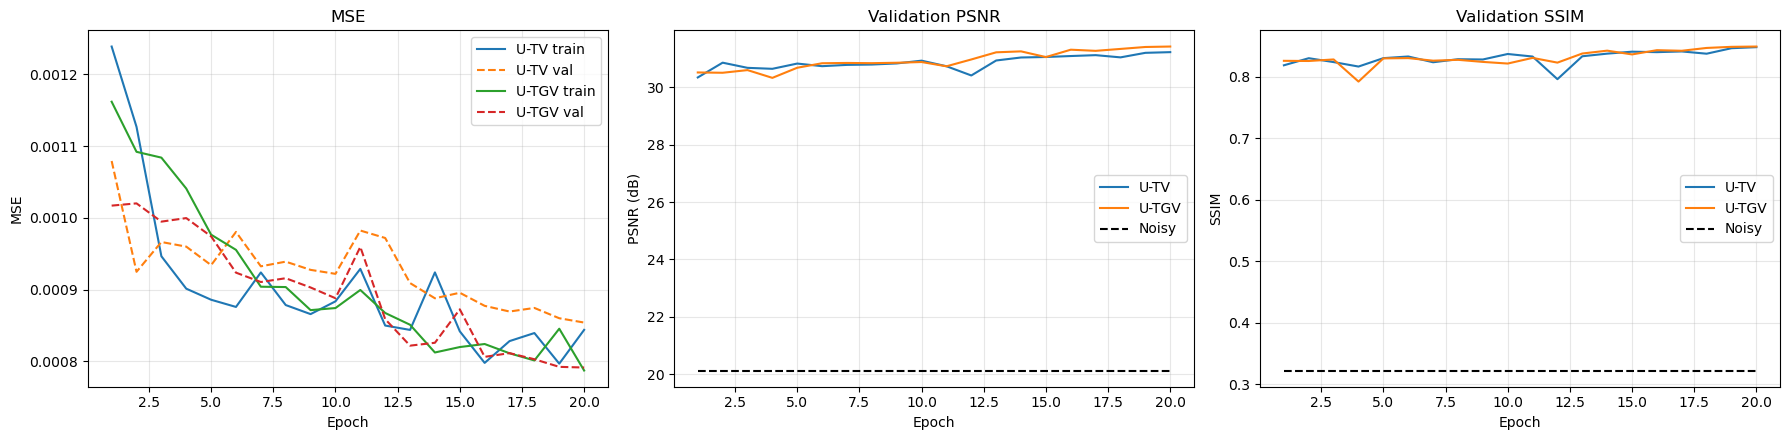

Saved: /Users/kyrillguba/Documents/Data Analytics MSc/Thesis/Python/cleaned_pipeline/results/training/u_tv_u_tgv_curves.png


In [7]:
history_tv = pd.read_csv(Path(args_tv.checkpoint_dir) / "history.csv")
history_tgv = pd.read_csv(Path(args_tgv.checkpoint_dir) / "history.csv")

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

axes[0].plot(history_tv["epoch"], history_tv["train_mse"], label="U-TV train")
axes[0].plot(history_tv["epoch"], history_tv["val_mse"], "--", label="U-TV val")
axes[0].plot(history_tgv["epoch"], history_tgv["train_mse"], label="U-TGV train")
axes[0].plot(history_tgv["epoch"], history_tgv["val_mse"], "--", label="U-TGV val")
axes[0].set(title="MSE", xlabel="Epoch", ylabel="MSE")

axes[1].plot(history_tv["epoch"], history_tv["val_psnr"], label="U-TV")
axes[1].plot(history_tgv["epoch"], history_tgv["val_psnr"], label="U-TGV")
axes[1].plot(history_tv["epoch"], history_tv["noisy_psnr"], "k--", label="Noisy")
axes[1].set(title="Validation PSNR", xlabel="Epoch", ylabel="PSNR (dB)")

axes[2].plot(history_tv["epoch"], history_tv["val_ssim"], label="U-TV")
axes[2].plot(history_tgv["epoch"], history_tgv["val_ssim"], label="U-TGV")
axes[2].plot(history_tv["epoch"], history_tv["noisy_ssim"], "k--", label="Noisy")
axes[2].set(title="Validation SSIM", xlabel="Epoch", ylabel="SSIM")

for axis in axes:
    axis.grid(alpha=0.3)
    axis.legend()

figure_path = PROJECT_ROOT / "results" / "training" / "u_tv_u_tgv_curves.png"
figure_path.parent.mkdir(parents=True, exist_ok=True)
fig.tight_layout()
fig.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", figure_path)
